<a href="https://colab.research.google.com/github/alessarana90-hue/ML/blob/main/magDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import important library

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
!pip install tensorflow

In [ ]:
# Step 1: Import important libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout
from tensorflow.keras.metrics import MeanSquaredError, MeanAbsoluteError
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional, Input, BatchNormalization
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error
import math
from tensorflow.keras.layers import LayerNormalization, MultiHeadAttention, Dense, Dropout, GlobalAveragePooling1D, Layer, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.layers import GRU

# Upload dataset

In [ ]:
# Step 2: Upload the dataset
df = pd.read_csv('/content/drive/MyDrive/The Pacific Ring of Fire.csv')

In [ ]:
df .head(5)

,id,time,latitude,longitude,depth,magnitude,place,tsunami,alert,felt,...,status,sig,net,nst,dmin,gap,magType,type,title,location
0,us6000pfs7,12/26/2024 21:02,30.4847,141.8463,10.000,5.7,"Izu Islands, Japan region",0,green,NaN,...,reviewed,500,us,103.0,3.142,92.0,mww,earthquake,"M 5.7 - Izu Islands, Japan region","Izu Islands, Japan region"
1,us7000nzg7,12/17/2024 4:09,31.0904,130.2373,165.486,5.2,"20 km SSW of Makurazaki, Japan",0,NaN,1.0,...,reviewed,416,us,88.0,0.456,82.0,mb,earthquake,"M 5.2 - 20 km SSW of Makurazaki, Japan","20 km SSW of Makurazaki, Japan"
2,us7000ny8l,12/12/2024 19:55,30.5632,141.9457,10.000,5.1,"Izu Islands, Japan region",0,NaN,NaN,...,reviewed,400,us,87.0,3.125,119.0,mb,earthquake,"M 5.1 - Izu Islands, Japan region","Izu Islands, Japan region"
3,us7000nvxl,12/4/2024 16:53,24.8543,128.0555,10.000,5.0,"146 km SSE of Itoman, Japan",0,NaN,NaN,...,reviewed,385,us,120.0,1.983,103.0,mb,earthquake,"M 5.0 - 146 km SSE of Itoman, Japan","146 km SSE of Itoman, Japan"
4,us7000nv3a,11/30/2024 8:46,25.3021,126.0218,49.015,5.7,"91 km NE of Hirara, Japan",0,green,3.0,...,reviewed,501,us,257.0,1.866,62.0,mww,earthquake,"M 5.7 - 91 km NE of Hirara, Japan","91 km NE of Hirara, Japan"


In [ ]:
df.shape

(27759, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27759 entries, 0 to 27758
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         27759 non-null  object 
 1   time       27759 non-null  object 
 2   latitude   27759 non-null  float64
 3   longitude  27759 non-null  float64
 4   depth      27759 non-null  float64
 5   magnitude  27759 non-null  float64
 6   place      27759 non-null  object 
 7   tsunami    27759 non-null  int64  
 8   alert      1480 non-null   object 
 9   felt       3221 non-null   float64
 10  cdi        3221 non-null   float64
 11  mmi        5460 non-null   float64
 12  country    27759 non-null  object 
 13  status     27759 non-null  object 
 14  sig        27759 non-null  int64  
 15  net        27759 non-null  object 
 16  nst        7991 non-null   float64
 17  dmin       4468 non-null   float64
 18  gap        10205 non-null  float64
 19  magType    27759 non-null  object 
 20  type  

In [ ]:
print("Missing values in each feature:")
print(df.isnull().sum())

Missing values in each feature:
id               0
time             0
latitude         0
longitude        0
depth            0
magnitude        0
place            0
tsunami          0
alert        26279
felt         24538
cdi          24538
mmi          22299
country          0
status           0
sig              0
net              0
nst          19768
dmin         23291
gap          17554
magType          0
type             0
title            0
location         0
dtype: int64


# Preprocessing

In [ ]:
df.drop(['id'], axis=1, inplace=True)
df.drop(['alert'], axis=1, inplace=True)
df.drop(['mmi'], axis=1, inplace=True)
df.drop(['status'], axis=1, inplace=True)
df.drop(['sig'], axis=1, inplace=True)
df.drop(['net'], axis=1, inplace=True)
df.drop(['nst'], axis=1, inplace=True)
df.drop(['dmin'], axis=1, inplace=True)
df.drop(['gap'], axis=1, inplace=True)
df.drop(['magType'], axis=1, inplace=True)
df.drop(['type'], axis=1, inplace=True)
df.drop(['title'], axis=1, inplace=True)
df.drop(['location'], axis=1, inplace=True)

In [ ]:
df.head(5)

,time,latitude,longitude,depth,magnitude,place,tsunami,felt,cdi,country
0,12/26/2024 21:02,30.4847,141.8463,10.000,5.7,"Izu Islands, Japan region",0,NaN,NaN,Japan region
1,12/17/2024 4:09,31.0904,130.2373,165.486,5.2,"20 km SSW of Makurazaki, Japan",0,1.0,2.2,Japan
2,12/12/2024 19:55,30.5632,141.9457,10.000,5.1,"Izu Islands, Japan region",0,NaN,NaN,Japan region
3,12/4/2024 16:53,24.8543,128.0555,10.000,5.0,"146 km SSE of Itoman, Japan",0,NaN,NaN,Japan
4,11/30/2024 8:46,25.3021,126.0218,49.015,5.7,"91 km NE of Hirara, Japan",0,3.0,3.8,Japan


In [ ]:
df.drop(['depth'], axis=1, inplace=True)
#df.drop(['place'], axis=1, inplace=True)
#df.drop(['tsunami'], axis=1, inplace=True)
#df.drop(['felt'], axis=1, inplace=True)
#df.drop(['cdi'], axis=1, inplace=True)
df.drop(['country'], axis=1, inplace=True)

In [ ]:
df.head(5)

,time,latitude,longitude,magnitude,place,tsunami,felt,cdi
0,12/26/2024 21:02,30.4847,141.8463,5.7,"Izu Islands, Japan region",0,NaN,NaN
1,12/17/2024 4:09,31.0904,130.2373,5.2,"20 km SSW of Makurazaki, Japan",0,1.0,2.2
2,12/12/2024 19:55,30.5632,141.9457,5.1,"Izu Islands, Japan region",0,NaN,NaN
3,12/4/2024 16:53,24.8543,128.0555,5.0,"146 km SSE of Itoman, Japan",0,NaN,NaN
4,11/30/2024 8:46,25.3021,126.0218,5.7,"91 km NE of Hirara, Japan",0,3.0,3.8


In [ ]:
df.drop(['latitude'], axis=1, inplace=True)
df.drop(['longitude'], axis=1, inplace=True)
#df.drop(['depth'], axis=1, inplace=True)
#df.drop(['latitude'], axis=1, inplace=True)

In [ ]:
df.head(5)

,time,magnitude,place,tsunami,felt,cdi
0,12/26/2024 21:02,5.7,"Izu Islands, Japan region",0,NaN,NaN
1,12/17/2024 4:09,5.2,"20 km SSW of Makurazaki, Japan",0,1.0,2.2
2,12/12/2024 19:55,5.1,"Izu Islands, Japan region",0,NaN,NaN
3,12/4/2024 16:53,5.0,"146 km SSE of Itoman, Japan",0,NaN,NaN
4,11/30/2024 8:46,5.7,"91 km NE of Hirara, Japan",0,3.0,3.8


In [ ]:
df.head(5)

,time,magnitude,place,tsunami,felt,cdi
0,12/26/2024 21:02,5.7,"Izu Islands, Japan region",0,NaN,NaN
1,12/17/2024 4:09,5.2,"20 km SSW of Makurazaki, Japan",0,1.0,2.2
2,12/12/2024 19:55,5.1,"Izu Islands, Japan region",0,NaN,NaN
3,12/4/2024 16:53,5.0,"146 km SSE of Itoman, Japan",0,NaN,NaN
4,11/30/2024 8:46,5.7,"91 km NE of Hirara, Japan",0,3.0,3.8


In [ ]:
# Handle remaining missing values
# Fill numeric columns with the mean
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [ ]:
# Fill categorical columns with the mode (most frequent value)
categorical_cols = df.select_dtypes(include=[object]).columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Detect and manage outliers using IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

# Apply outlier removal to numerical columns
for col in numeric_cols:
    df = remove_outliers(df, col)

<ipython-input-19-969f4d23c9fb>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
df.shape

(23413, 6)

In [ ]:
df.head(5)

,time,magnitude,place,tsunami,felt,cdi
0,12/26/2024 21:02,5.7,"Izu Islands, Japan region",0,33.967401,3.782614
2,12/12/2024 19:55,5.1,"Izu Islands, Japan region",0,33.967401,3.782614
3,12/4/2024 16:53,5.0,"146 km SSE of Itoman, Japan",0,33.967401,3.782614
7,11/25/2024 15:37,5.0,"Izu Islands, Japan region",0,33.967401,3.782614
12,11/9/2024 5:00,5.0,"Izu Islands, Japan region",0,33.967401,3.782614


In [ ]:
# Handle categorical data (assuming 'description' is a column with string values)
if 'description' in df.columns:
    df.drop(['description'], axis=1, inplace=True)

In [ ]:
# Ensure all features are numeric
for column in df.columns:
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])

In [ ]:
df.head(5)

,time,magnitude,place,tsunami,felt,cdi
0,7141,5.7,17247,0,33.967401,3.782614
2,6138,5.1,17247,0,33.967401,3.782614
3,7639,5.0,4017,0,33.967401,3.782614
7,5110,5.0,17247,0,33.967401,3.782614
12,5855,5.0,17247,0,33.967401,3.782614


In [ ]:
# Step 3: Do preprocessing
# Extract features and target
X = df.drop(columns=['magnitude'])
y = df['magnitude']

In [ ]:
X.shape

(23413, 5)

In [ ]:
X.head(5)

,time,place,tsunami,felt,cdi
0,7141,17247,0,33.967401,3.782614
2,6138,17247,0,33.967401,3.782614
3,7639,4017,0,33.967401,3.782614
7,5110,17247,0,33.967401,3.782614
12,5855,17247,0,33.967401,3.782614


In [ ]:
# Fit a Random Forest to determine feature importances
#rf = RandomForestRegressor()
#rf.fit(X, y)

# Get feature importances and sort them
#importances = rf.feature_importances_
#indices = np.argsort(importances)[::-1]
#selected_features = X.columns[indices[:15]]  # Select top 20 features

# Update X to include only the selected features
#X_selected = X[selected_features]

In [ ]:
# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Spliting Dataset

In [ ]:
# Step 1: Split data into 80% training+validation and 20% testing
X_text_train_val, X_text_test, y_train_val, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 2: Split the 80% training+validation set into 70% training and 10% validation
X_text_train, X_text_val, y_train, y_val = train_test_split(X_text_train_val, y_train_val, test_size=0.125, random_state=42)

# Check the shapes to ensure the correct split
print(f"Training set size: {X_text_train.shape[0]} samples")
print(f"Validation set size: {X_text_val.shape[0]} samples")
print(f"Testing set size: {X_text_test.shape[0]} samples")

Training set size: 16388 samples
Validation set size: 2342 samples
Testing set size: 4683 samples


In [ ]:
# Reshape data for LSTM input (samples, timesteps, features)
X_text_train_reshaped = X_text_train.reshape((X_text_train.shape[0], 1, X_text_train.shape[1]))
X_text_val_reshaped = X_text_val.reshape((X_text_val.shape[0], 1, X_text_val.shape[1]))
X_text_test_reshaped = X_text_test.reshape((X_text_test.shape[0], 1, X_text_test.shape[1]))

# DL Models

In [ ]:
# Hyperparameters
lstm_units = 128
dropout_rate = 0.2
learning_rate = 0.001
batch_size = 32
epochs = 100

LSTM Model

In [ ]:
# Build the LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(lstm_units, return_sequences=True, input_shape=(X_text_train_reshaped.shape[1], X_text_train_reshaped.shape[2])))
model_lstm.add(BatchNormalization())
model_lstm.add(Dropout(dropout_rate))
model_lstm.add(LSTM(lstm_units // 2, return_sequences=True))
model_lstm.add(BatchNormalization())
model_lstm.add(Dropout(dropout_rate))
model_lstm.add(LSTM(lstm_units // 4))
model_lstm.add(BatchNormalization())
model_lstm.add(Dropout(dropout_rate))
model_lstm.add(Dense(64))
model_lstm.add(Dropout(dropout_rate))
model_lstm.add(Dense(32))
model_lstm.add(Dense(1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile the model
# Compile the model with specified learning rate
optimizer = Adam(learning_rate=learning_rate)
model_lstm.compile(optimizer=optimizer, loss='mean_squared_error')

In [ ]:
# Train the model
history_lstm = model_lstm.fit(X_text_train_reshaped, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_text_val_reshaped, y_val), verbose=1)

Epoch 1/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 10.7729 - val_loss: 0.2284
Epoch 2/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.5359 - val_loss: 0.2115
Epoch 3/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3768 - val_loss: 0.2143
Epoch 4/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.3123 - val_loss: 0.2124
Epoch 5/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.2768 - val_loss: 0.2130
Epoch 6/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.2507 - val_loss: 0.2111
Epoch 7/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.2291 - val_loss: 0.2102
Epoch 8/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.2305 - val_loss: 0.2100
Epoch 9/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.2333 - val_loss: 0.2098
Epoch 10/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.2242 - val_loss: 0.2164
Epoch 11/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.2259 - val_loss: 0.2081
Epoch 12/100
608/608 ━━

In [ ]:
# Predict and evaluate LSTM model
predictions_val_lstm = model_lstm.predict(X_text_val_reshaped)
predictions_test_lstm = model_lstm.predict(X_text_test_reshaped)

In [ ]:
# RMSE validation and testing
rmse_val_lstm = np.sqrt(mean_squared_error(y_val, predictions_val_lstm))
rmse_test_lstm = np.sqrt(mean_squared_error(y_test, predictions_test_lstm))

# R-squared validation and testing
r2_val_lstm = r2_score(y_val, predictions_val_lstm)
r2_test_lstm = r2_score(y_test, predictions_test_lstm)

print(f"LSTM - RMSE Validation: {rmse_val_lstm}, RMSE Testing: {rmse_test_lstm}")
print(f"LSTM - R-squared Validation: {r2_val_lstm}, R-squared Testing: {r2_test_lstm}")

In [ ]:
# Mean Absolute Error validation
mae = MeanAbsoluteError()
mae.update_state(y_val, predictions_val_lstm)
mae_result = mae.result().numpy()
print(f'Mean Absolute Error for val: {mae_result}')

# Mean Absolute Error testing
mae.update_state(y_test, predictions_test_lstm)
mae_result = mae.result().numpy()
print(f'Mean Absolute Error for testing: {mae_result}')

Mean Absolute Error for val: 0.28314176201820374
Mean Absolute Error for testing: 0.28129374980926514


In [ ]:
mse = mean_squared_error(y_val, predictions_val_lstm)
print("Mean Squared Error (MSE) for val:", mse)

mse = mean_squared_error(y_test, predictions_test_lstm)
print("Mean Squared Error (MSE) for testing:", mse)

Mean Squared Error (MSE) for val: 0.11837263975907632
Mean Squared Error (MSE) for testing: 0.11604289708001134


Text(0.5, 0, 'Epochs')

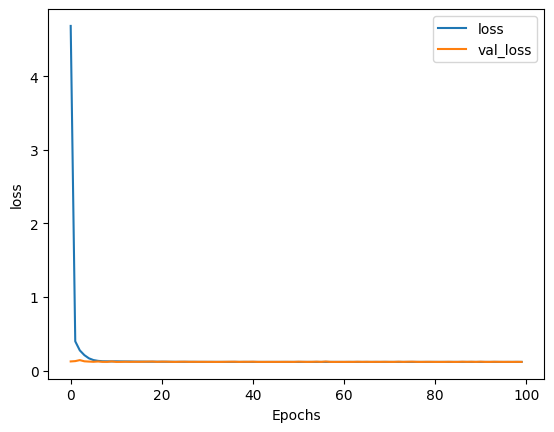

In [ ]:
pd.DataFrame(history_lstm.history)
pd.DataFrame(history_lstm.history)[['loss','val_loss']].plot()
plt.ylabel('loss')
plt.xlabel('Epochs')

In [ ]:
# Print real vs predicted values for test set
y_test_pred = model_lstm.predict(X_text_test_reshaped)

print("\nTest Set - Real vs Predicted:")
for real, predicted in zip(y_test, y_test_pred):
    print(f"Real: {real}, Predicted: {predicted}")

147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Test Set - Real vs Predicted:
Real: 6.0, Predicted: [5.361854]
Real: 5.2, Predicted: [5.354632]
Real: 5.0, Predicted: [5.355274]
Real: 5.9, Predicted: [5.356287]
Real: 5.6, Predicted: [5.352198]
Real: 5.0, Predicted: [5.352387]
Real: 5.98, Predicted: [5.3559227]
Real: 5.4, Predicted: [5.3638496]
Real: 5.3, Predicted: [5.353745]
Real: 5.0, Predicted: [5.355897]
Real: 5.2, Predicted: [5.3517084]
Real: 6.1, Predicted: [5.361041]
Real: 5.8, Predicted: [5.352439]
Real: 5.0, Predicted: [5.3544145]
Real: 5.0, Predicted: [5.3515515]
Real: 5.0, Predicted: [5.347313]
Real: 5.73, Predicted: [5.3559217]
Real: 5.0, Predicted: [5.3559494]
Real: 5.3, Predicted: [5.3512607]
Real: 6.1, Predicted: [5.362666]
Real: 5.3, Predicted: [5.3600955]
Real: 5.1, Predicted: [5.3569384]
Real: 5.1, Predicted: [5.353362]
Real: 5.2, Predicted: [5.346333]
Real: 5.64, Predicted: [5.345292]
Real: 5.3, Predicted: [5.362853]
Real: 5.0, Predicted: [5.345723]
Real: 6.28, Predicted: [

GRU Model

In [ ]:
# Build the GRU model
model_gru = Sequential()
model_gru.add(GRU(128, return_sequences=True, input_shape=(X_text_train_reshaped.shape[1], X_text_train_reshaped.shape[2])))
model_gru.add(BatchNormalization())
model_gru.add(Dropout(dropout_rate))
model_gru.add(GRU(128 // 2, return_sequences=True))
model_gru.add(BatchNormalization())
model_gru.add(Dropout(dropout_rate))
model_gru.add(GRU(128 // 4))
model_gru.add(BatchNormalization())
model_gru.add(Dropout(dropout_rate))
model_gru.add(Dense(64))
model_gru.add(Dropout(dropout_rate))
model_gru.add(Dense(32))
model_gru.add(Dense(1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile the model with a new instance of the optimizer
optimizer_gru = Adam(learning_rate=learning_rate)
model_gru.compile(optimizer=optimizer_gru, loss='mean_squared_error')

In [ ]:
# Train the model
history_gru = model_gru.fit(X_text_train_reshaped, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_text_val_reshaped, y_val), verbose=1)

Epoch 1/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - loss: 11.2527 - val_loss: 0.1423
Epoch 2/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.4769 - val_loss: 0.1241
Epoch 3/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.3072 - val_loss: 0.1187
Epoch 4/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.2302 - val_loss: 0.1325
Epoch 5/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1839 - val_loss: 0.1232
Epoch 6/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.1534 - val_loss: 0.1182
Epoch 7/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.1378 - val_loss: 0.1238
Epoch 8/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.1299 - val_loss: 0.1198
Epoch 9/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1281 - val_loss: 0.1192
Epoch 10/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.1253 - val_loss: 0.1185
Epoch 11/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1263 - val_loss: 0.1325
Epoch 12/100
513/513 ━━━━

Text(0.5, 0, 'Epochs')

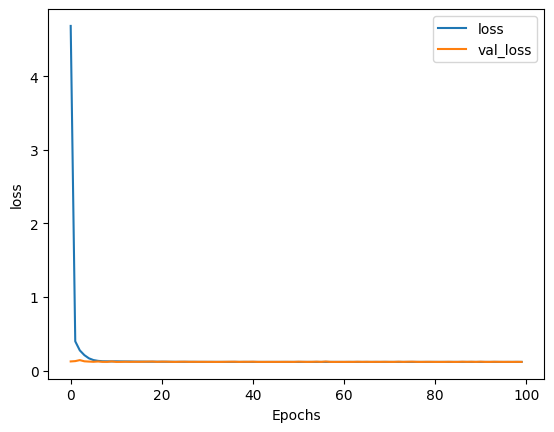

In [ ]:
pd.DataFrame(history_gru.history)
pd.DataFrame(history_lstm.history)[['loss','val_loss']].plot()
plt.ylabel('loss')
plt.xlabel('Epochs')

In [ ]:
# Predict and evaluate GRU model
predictions_val_gru = model_gru.predict(X_text_val_reshaped)
predictions_test_gru = model_gru.predict(X_text_test_reshaped)

74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
# RMSE validation and testing
rmse_val_gru = np.sqrt(mean_squared_error(y_val, predictions_val_gru))
rmse_test_gru = np.sqrt(mean_squared_error(y_test, predictions_test_gru))

# R-squared validation and testing
r2_val_gru = r2_score(y_val, predictions_val_gru)
r2_test_gru = r2_score(y_test, predictions_test_gru)

print(f"GRU Model - RMSE (Validation): {rmse_val_gru}, R^2 (Validation): {r2_val_gru}")
print(f"GRU Model - RMSE (Testing): {rmse_test_gru}, R^2 (Testing): {r2_test_gru}")

GRU Model - RMSE (Validation): 0.34531173118799563, R^2 (Validation): -0.006815280569580029
GRU Model - RMSE (Testing): 0.3420622645889222, R^2 (Testing): -0.007380077503922555


In [ ]:
# Mean Absolute Error validation
mae = MeanAbsoluteError()
mae.update_state(y_val, predictions_val_gru)
mae_result = mae.result().numpy()
print(f'Mean Absolute Error for val: {mae_result}')

# Mean Absolute Error testing
mae.update_state(y_test, predictions_test_gru)
mae_result = mae.result().numpy()
print(f'Mean Absolute Error for testing: {mae_result}')

Mean Absolute Error for val: 0.274382084608078
Mean Absolute Error for testing: 0.27287283539772034


In [ ]:
mse = mean_squared_error(y_val, predictions_val_gru)
print("Mean Squared Error (MSE) for val:", mse)

mse = mean_squared_error(y_test, predictions_test_gru)
print("Mean Squared Error (MSE) for testing:", mse)

Mean Squared Error (MSE) for val: 0.11924019169605055
Mean Squared Error (MSE) for testing: 0.11700659285570182


BiLSTM Model

In [ ]:
# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(lstm_units, return_sequences=True), input_shape=(X_text_train_reshaped.shape[1], X_text_train_reshaped.shape[2])))
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))
model.add(Bidirectional(LSTM(lstm_units // 2, return_sequences=True)))
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))
model.add(Bidirectional(LSTM(lstm_units // 4)))
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))
model.add(Dense(64))
model.add(Dropout(dropout_rate))
model.add(Dense(32))
model.add(Dense(1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile the model with specified learning rate
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='mean_squared_error')

In [ ]:
model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_18                │ (None, 1, 256)         │       136,192 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 1, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_19                │ (None, 1, 128)         │       164,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_20                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 349,825 (1.33 MB)

 Trainable params: 348,929 (1.33 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# Train the model
history = model.fit(X_text_train_reshaped, y_train, epochs=epochs, batch_size=batch_size, validation_data=([ X_text_val_reshaped], y_val), verbose=1)

Epoch 1/100
511/513 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 11.8115

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1163
Received: inputs=('Tensor(shape=(None, 1, 4))',)
  warnings.warn(msg)


513/513 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - loss: 11.7710 - val_loss: 0.1740
Epoch 2/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 0.5321 - val_loss: 0.1341
Epoch 3/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.3006 - val_loss: 0.1381
Epoch 4/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.2278 - val_loss: 0.1200
Epoch 5/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.1734 - val_loss: 0.1243
Epoch 6/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.1464 - val_loss: 0.1205
Epoch 7/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.1430 - val_loss: 0.1406
Epoch 8/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.1304 - val_loss: 0.1192
Epoch 9/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 0.1299 - val_loss: 0.1197
Epoch 10/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.1291 - val_loss: 0.1239
Epoch 11/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.1295 - val_loss: 0.1315
Epoch 12/100
513/513 ━━━━━━━━━━━━

In [ ]:
# Make predictions on the test data
predictions_val = model.predict(X_text_val_reshaped)
predictions_test = model.predict(X_text_test_reshaped)

74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
# rmse validation
rmse = np.sqrt(mean_squared_error(y_val, predictions_val))
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 0.344563137073074


In [ ]:
# rmse testing
rmse = np.sqrt(mean_squared_error(y_test, predictions_test))
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 0.3411077517423425


In [ ]:
# Mean Absolute Error validation
mae = MeanAbsoluteError()
mae.update_state(y_val, predictions_val)
mae_result = mae.result().numpy()
print(f'Mean Absolute Error: {mae_result}')

Mean Absolute Error: 0.2854621410369873


In [ ]:
# Mean Absolute Error testing
mae = MeanAbsoluteError()
mae.update_state(y_test, predictions_test)
mae_result = mae.result().numpy()
print(f'Mean Absolute Error: {mae_result}')

Mean Absolute Error: 0.2826264798641205


In [ ]:
mse = mean_squared_error(y_val, predictions_val)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.118723755429638


In [ ]:
mse = mean_squared_error(y_test, predictions_test)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.11635449829871557


In [ ]:
# Calculate R-squared testing
r2 = r2_score(y_test, predictions_test)
print("R-squared (R^2):", r2)

R-squared (R^2): -0.0017658035615402135


In [ ]:
# Calculate R-squared validation
r2 = r2_score(y_val, predictions_val)
print("R-squared (R^2):", r2)

R-squared (R^2): -0.0024547045165839165


Text(0.5, 0, 'Epochs')

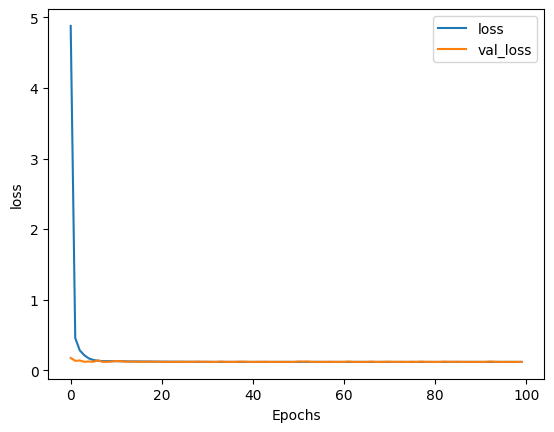

In [ ]:
pd.DataFrame(history.history)
pd.DataFrame(history.history)[['loss','val_loss']].plot()
plt.ylabel('loss')
plt.xlabel('Epochs')

In [ ]:
# Print real vs predicted values for test set
y_test_pred = model.predict(X_text_test_reshaped)

print("\nTest Set - Real vs Predicted:")
for real, predicted in zip(y_test, y_test_pred):
    print(f"Real: {real}, Predicted: {predicted}")

147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Test Set - Real vs Predicted:
Real: 6.0, Predicted: [5.3687205]
Real: 5.2, Predicted: [5.3665366]
Real: 5.0, Predicted: [5.3538036]
Real: 5.9, Predicted: [5.35338]
Real: 5.6, Predicted: [5.3584676]
Real: 5.0, Predicted: [5.3595405]
Real: 5.98, Predicted: [5.369635]
Real: 5.4, Predicted: [5.367796]
Real: 5.3, Predicted: [5.367021]
Real: 5.0, Predicted: [5.36857]
Real: 5.2, Predicted: [5.359922]
Real: 6.1, Predicted: [5.365033]
Real: 5.8, Predicted: [5.3582006]
Real: 5.0, Predicted: [5.3693347]
Real: 5.0, Predicted: [5.3585052]
Real: 5.0, Predicted: [5.360185]
Real: 5.73, Predicted: [5.3696465]
Real: 5.0, Predicted: [5.3694634]
Real: 5.3, Predicted: [5.360052]
Real: 6.1, Predicted: [5.359308]
Real: 5.3, Predicted: [5.365544]
Real: 5.1, Predicted: [5.3655124]
Real: 5.1, Predicted: [5.359928]
Real: 5.2, Predicted: [5.37293]
Real: 5.64, Predicted: [5.3603835]
Real: 5.3, Predicted: [5.3583264]
Real: 5.0, Predicted: [5.3626037]
Real: 6.28, Predicted: 

BiGRU Model

In [ ]:
# Build the BiGRU model
model_bigru = Sequential()
model_bigru.add(Bidirectional(GRU(lstm_units, return_sequences=True), input_shape=(X_text_train_reshaped.shape[1], X_text_train_reshaped.shape[2])))
model_bigru.add(BatchNormalization())
model_bigru.add(Dropout(dropout_rate))
model_bigru.add(Bidirectional(GRU(lstm_units // 2, return_sequences=True)))
model_bigru.add(BatchNormalization())
model_bigru.add(Dropout(dropout_rate))
model_bigru.add(Bidirectional(GRU(lstm_units // 4)))
model_bigru.add(BatchNormalization())
model_bigru.add(Dropout(dropout_rate))
model_bigru.add(Dense(64))
model_bigru.add(Dropout(dropout_rate))
model_bigru.add(Dense(32))
model_bigru.add(Dense(1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile the model
# Compile the model with a new instance of the optimizer
optimizer_bigru = Adam(learning_rate=learning_rate)
model_bigru.compile(optimizer=optimizer_bigru, loss='mean_squared_error')

In [ ]:
# Train the model
history_bigru = model_bigru.fit(X_text_train_reshaped, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_text_val_reshaped, y_val), verbose=1)

Epoch 1/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - loss: 11.8841 - val_loss: 0.1258
Epoch 2/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.5612 - val_loss: 0.1464
Epoch 3/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.3208 - val_loss: 0.1388
Epoch 4/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.2356 - val_loss: 0.1270
Epoch 5/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.1795 - val_loss: 0.1308
Epoch 6/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.1511 - val_loss: 0.1213
Epoch 7/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.1329 - val_loss: 0.1218
Epoch 8/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.1288 - val_loss: 0.1209
Epoch 9/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.1280 - val_loss: 0.1188
Epoch 10/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.1253 - val_loss: 0.1344
Epoch 11/100
513/513 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.1307 - val_loss: 0.1189
Epoch 12/100
513/513 ━━

In [ ]:
# Predict and evaluate BiGRU model
predictions_val_bigru = model_bigru.predict(X_text_val_reshaped)
predictions_test_bigru = model_bigru.predict(X_text_test_reshaped)

74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
# RMSE validation and testing
rmse_val_bigru = np.sqrt(mean_squared_error(y_val, predictions_val_bigru))
rmse_test_bigru = np.sqrt(mean_squared_error(y_test, predictions_test_bigru))

# R-squared validation and testing
r2_val_bigru = r2_score(y_val, predictions_val_bigru)
r2_test_bigru = r2_score(y_test, predictions_test_bigru)

print(f"BiGRU Model - RMSE (Validation): {rmse_val_bigru}, R^2 (Validation): {r2_val_bigru}")
print(f"BiGRU Model - RMSE (Testing): {rmse_test_bigru}, R^2 (Testing): {r2_test_bigru}")

BiGRU Model - RMSE (Validation): 0.34537549168662807, R^2 (Validation): -0.007187124125456412
BiGRU Model - RMSE (Testing): 0.3422054762086452, R^2 (Testing): -0.008223776140423578


In [ ]:
# Mean Absolute Error validation
mae = MeanAbsoluteError()
mae.update_state(y_val, predictions_val_bigru)
mae_result = mae.result().numpy()
print(f'Mean Absolute Error for val: {mae_result}')

# Mean Absolute Error testing
mae.update_state(y_test, predictions_test_bigru)
mae_result = mae.result().numpy()
print(f'Mean Absolute Error for testing: {mae_result}')

Mean Absolute Error for val: 0.27438777685165405
Mean Absolute Error for testing: 0.2729281485080719


In [ ]:
mse = mean_squared_error(y_val, predictions_val_bigru)
print("Mean Squared Error (MSE) for val:", mse)

mse = mean_squared_error(y_test, predictions_test_bigru)
print("Mean Squared Error (MSE) for testing:", mse)

Mean Squared Error (MSE) for val: 0.11928423025778011
Mean Squared Error (MSE) for testing: 0.11710458794718565


Text(0.5, 0, 'Epochs')

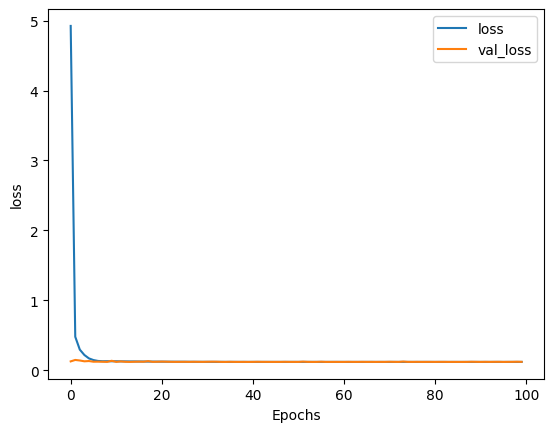

In [ ]:
pd.DataFrame(history_bigru.history)
pd.DataFrame(history_bigru.history)[['loss','val_loss']].plot()
plt.ylabel('loss')
plt.xlabel('Epochs')